In [13]:
import pandas as pd
df = pd.read_csv(r"C:\Users\J Sree Karthik\Data_Visualizations\data-viz-class-material\WHR2023.csv")

print("Original columns:", df.columns.tolist())

# Select correct columns explicitly
df_clean = df[[
    'Country name',
    'Ladder score',
    'Logged GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]].copy()

# Rename properly
df_clean.columns = [
    'Country',
    'Happiness_Score',
    'GDP',
    'Social_Support',
    'Life_Expectancy',
    'Freedom',
    'Generosity',
    'Corruption'
]

print(df_clean.head())

Original columns: ['Country name', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
       Country  Happiness_Score     GDP  Social_Support  Life_Expectancy  \
0      Finland            7.804  10.792           0.969           71.150   
1      Denmark            7.586  10.962           0.954           71.250   
2      Iceland            7.530  10.896           0.983           72.050   
3       Israel            7.473  10.639           0.943           72.697   
4  Netherlands            7.403  10.942           0.930           71.550   

   F

In [5]:
df = pd.read_csv(r"C:\Users\J Sree Karthik\Data_Visualizations\data-viz-class-material\WHR2023.csv")
print("Original columns:", df.columns.tolist())

df_subset = df.iloc[:, :9]  # Select only the first 9 columns
df_subset.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
                    'Life_Expectancy','Freedom','Generosity','Corruption']

print(f"Dataset: {len(df_subset)} countries, {len(df_subset.columns)} columns")
print(df_subset.head())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1213613232.py, line 1)

In [14]:
region_map = {
    'Finland': 'Western Europe',
    'Denmark': 'Western Europe',
    'Iceland': 'Western Europe',
    'Netherlands': 'Western Europe',
    'Sweden': 'Western Europe',
    'Norway': 'Western Europe',
    'Germany': 'Western Europe',
    'France': 'Western Europe',
    'Spain': 'Western Europe',

    'India': 'South Asia',
    'Pakistan': 'South Asia',
    'Bangladesh': 'South Asia',

    'China': 'East Asia',
    'Japan': 'East Asia',
    'South Korea': 'East Asia',

    'Nigeria': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa',
    'Congo (Kinshasa)': 'Sub-Saharan Africa',
    'Sierra Leone': 'Sub-Saharan Africa',

    'Brazil': 'Latin America',
    'Argentina': 'Latin America',
    'Mexico': 'Latin America'
}

df_clean['Region'] = df_clean['Country'].map(region_map)
df_clean = df_clean.dropna(subset=['Region'])

# task1

In [24]:
%pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 4.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 3.7 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 3.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 3.3 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.9 MB 3.3 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 3.0 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 2.9 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 2.8 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 2.9 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 2.9 MB/s eta 0:00:01
   ----------------

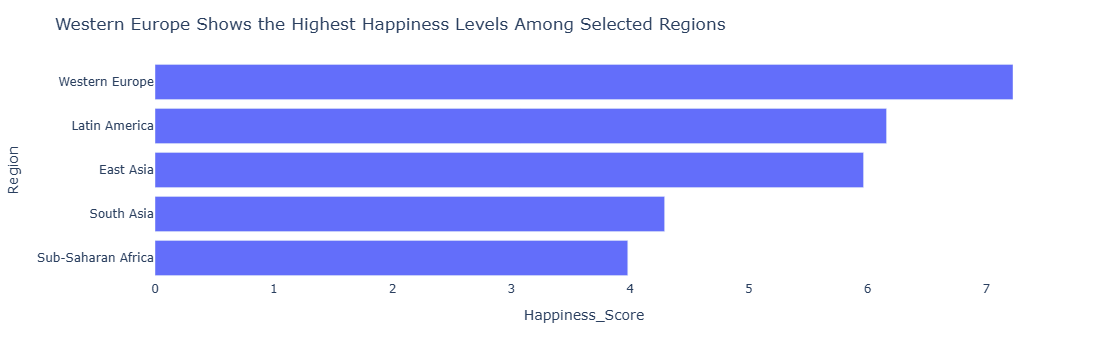

In [26]:
# 1. Install the missing library (You only need to run this once!)
!pip install plotly

# 2. Import the libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go # Added 'as go' which is standard practice

# 3. Your plotting code 
# (Note: Ensure 'region_avg' was successfully created in a previous cell)
region_avg = region_avg.sort_values('Happiness_Score')

fig1 = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h'
)

fig1.update_xaxes(range=[0, region_avg['Happiness_Score'].max()])

fig1.update_layout(
    title="Western Europe Shows the Highest Happiness Levels Among Selected Regions",
    plot_bgcolor='white'
)

fig1.show()

In [22]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects 
region_avg = region_avg.sort_values('Happiness_Score')

fig1 = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h'
)

fig1.update_xaxes(range=[0, region_avg['Happiness_Score'].max()])

fig1.update_layout(
    title="Western Europe Shows the Highest Happiness Levels Among Selected Regions",
    plot_bgcolor='white'
)

fig1.show()

ModuleNotFoundError: No module named 'plotly'

# Task-2

In [ ]:
import plotly.express as px

# Top and Bottom
top8 = df_clean.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

bottom8 = df_clean.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8])
combined = combined.sort_values('Happiness_Score')

# Global average
global_avg = df_clean['Happiness_Score'].mean()

# Plot
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    color_discrete_map={'Top 8': 'green', 'Bottom 8': 'red'}
)

fig.add_vline(x=global_avg, line_dash="dash")

fig.update_xaxes(range=[0, combined['Happiness_Score'].max()])

fig.update_layout(
    title="Top Countries Are Nearly Twice as Happy as the Lowest Ranked Ones",
    plot_bgcolor='white'
)

fig.show()

#Task 3

In [ ]:
import plotly.graph_objects as go

regions = ['Western Europe', 'Latin America', 'East Asia', 'Sub-Saharan Africa', 'South Asia']

# Filter dataset
subset = df_clean[df_clean['Region'].isin(regions)]

# Group averages
grouped = subset.groupby('Region')[['GDP', 'Freedom']].mean().reset_index()

print(grouped)

# Plot
fig3 = go.Figure()

fig3.add_trace(go.Bar(
    x=grouped['Region'],
    y=grouped['GDP'],
    name='GDP'
))

fig3.add_trace(go.Bar(
    x=grouped['Region'],
    y=grouped['Freedom'],
    name='Freedom'
))

fig3.update_layout(
    barmode='group',
    title="Western Europe Leads in Both Economic Strength and Personal Freedom Compared to Other Regions",
    xaxis_title="Region",
    yaxis_title="Average Value",
    plot_bgcolor='white'
)

fig3.show()